## BIS ADVANCED

In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct

import funciones_aux as fau

import funciones_dsa as fun_dsa


from matplotlib.colors import LinearSegmentedColormap, PowerNorm

### General todos los archivos

In [2]:
# Exploración carpeta raíz datos advanced

ruta_base_advanced = "../data/data_bis_advanced"

"""for raiz, dirs, files in os.walk(ruta_base_advanced):
    print(f"\nCarpeta: {raiz}")
    print("Subcarpetas:", dirs)
    print("Archivos:", files)"""

'for raiz, dirs, files in os.walk(ruta_base_advanced):\n    print(f"\nCarpeta: {raiz}")\n    print("Subcarpetas:", dirs)\n    print("Archivos:", files)'

In [3]:
ruta_base_advanced = "../data/data_bis_advanced"

"""
os.path.join: construye ruta para el SO
**: buscar en todas las subcarpetas del data_bis_advanced
recursive = True: para que mire en carpeta tras carpeta
    Si no está, ** no te recorre la estructura
glob.glob(...): función para buscar archivos por patrón
"""
todos_archivos_advanced = glob.glob(os.path.join(ruta_base_advanced, "**", "L03041035.*"), recursive=True)

"""for archivo in todos_archivos_advanced:
    probar_apertura_texto(archivo, 5)"""

'for archivo in todos_archivos_advanced:\n    probar_apertura_texto(archivo, 5)'

 ## Archivo .f_a

### Directamente sin pasar por el .csv

In [4]:
archivos_fa = fau.localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

#vista_preeliminar_texto(ruta_fa, 10)

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a


### Carga de archivo
Cargar el archivo .f_a del monitor BIS como un fichero de texto estructurado. 

El separador principal es el carácter |, que delimita una columna temporal (Time) y una columna con la información espectral (Spectra).

La columna Spectra contiene 60 valores por instante temporal, separados por comas, que corresponden a las bandas de frecuencia de la matriz DSA. Estas bandas abarcan desde 0.5 Hz hasta 30 Hz con una resolución de 0.5 Hz.

Una vez expandida la columna espectral, se obtiene una matriz de dimensiones tiempo × frecuencia, que puede representarse como imagen en forma de mapa de calor. En dicha representación, el eje horizontal corresponde al tiempo, el eje vertical a la frecuencia y el color a la intensidad espectral.

La resolución temporal real se verifica calculando la diferencia entre marcas temporales consecutivas. En los datos analizados, esta separación es de 1 segundo por fila.

Los valores espectrales aparecen almacenados como enteros escalados. Tras aplicar un factor de corrección de 1/100, el mapa de color se interpreta como potencia espectral en dB, pendiente de confirmación definitiva con la documentación técnica del dispositivo.

In [5]:
tiempo_fa_unilat, dsa_unilat = fau.cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa_unilat.shape)
print("Frecuencias:", dsa_unilat.columns.min(), "a", dsa_unilat.columns.max(), "Hz")

# salto entre una banda de frecuencia y la siguiente. La diferencia entre columnas consecutivas es 0.5
print("Resolución en frecuencia:", dsa_unilat.columns[1] - dsa_unilat.columns[0], "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz
Resolución en frecuencia: 0.5 Hz


In [6]:
"""
Si se quiere recomponer el df final en el que hay 61 columnas:
 - 1º: Time. Se fuerza a que cuando se convierta en columna se llame Time
 - siguientes: frecuencias de 0.5 Hz a 30 Hz

"""
df_final = pd.concat([tiempo_fa_unilat.rename("Time"), dsa_unilat], axis=1)
display(df_final[:8])

,Time,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,...,25.5,26.0,26.5,27.0,27.5,28.0,28.5,29.0,29.5,30.0
0,2026-03-04 10:35:21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2026-03-04 10:35:22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,2026-03-04 10:35:23,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,2026-03-04 10:35:24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,2026-03-04 10:35:25,93.56,98.12,97.43,100.48,99.82,96.09,93.46,98.54,101.14,...,69.31,75.63,78.86,82.60,84.23,82.09,77.32,79.75,80.81,76.02
5,2026-03-04 10:35:26,93.57,98.12,97.42,100.45,99.78,96.03,93.42,98.51,101.11,...,69.31,75.62,78.83,82.58,84.20,82.02,77.30,79.74,80.79,76.00
6,2026-03-04 10:35:27,93.57,98.11,97.36,100.34,99.67,95.88,93.34,98.42,101.00,...,69.25,75.61,78.76,82.46,84.08,81.82,77.24,79.69,80.73,75.94
7,2026-03-04 10:35:28,93.56,98.08,97.23,100.16,99.50,95.72,93.27,98.28,100.81,...,69.10,75.59,78.65,82.26,83.86,81.53,77.12,79.60,80.65,75.86


## Archivo .spa

### BIS Unilateral: canales

**Mapa de pegatinas**
 - Pegatina 1 (Referencia): Va en el centro de la frente. Es el punto "cero" o base contra el que se va a comparar todo lo demás.
 - Pegatina 2 (Tierra / Ground): Va al lado de la 1. No recoge ondas cerebrales, solo sirve para absorber el "ruido" eléctrico de tu cuerpo (como un pararrayos) para que la señal sea limpia.
 - Pegatina 3 (Explorador 1): Va hacia la zona temporal (sien).
 - Pegatina 4 (Explorador 2): Va un poco más al extremo, justo por encima de la ceja/ojo.


### Canales

**Canal 1 (Ch 1 -> variables sin sufijo)**
 - Corresponde a la señal principal captada por la primera zona de exploración de tu pegatina.
 - Datos válidos y reales para casi todo. Número BIS (DB13U01 o similar), tasa de supresión (SR),  EMG, y la calidad de señal (SQI e impedancia).
 
**Canal 2 (Ch 2 -> variables terminadas en _2)**
 - Corresponde a la señal captada por la segunda zona de exploración de la pegatina.
 - El algoritmo no suele calcular variables matemáticas complejas (como el número BIS o el SEF) solo para este segundo canal físico, por lo que esos campos aparecerán con el código de error -3276.8 (dato inválido).
 - Las únicas variables con números reales aquí serán las físicas de los electrodos, como la Calidad de la Señal (SQI10_2) y la Impedancia.
 
**Canal Combinado (Ch12 -> variables terminadas en _3)**
 - Este no es un electrodo físico real. Es un "canal virtual" o derivado que el monitor crea combinando la información del Canal 1 y del Canal 2.
 - Contiene los valores finales procesados que el monitor muestra en la pantalla.
 - Los valores del Canal 12 (terminados en _3) suelen ser idénticos a los del Canal 1 (sin sufijo). El algoritmo vuelca el cálculo definitivo en ambos sitios.

En este caso unilateral se pueden limpiar los campos acabados en _2 y _3.
 - Al eliminar las columnas _3 (Canal 12): Como es un combinado de los canales 1 y 2 los valores son idénticos al canal 1.
 - Al eliminar las columnas _2 (Canal 2): Las variables del canal 2 están en nulo salvo la calidad de la señal y la impedancia.
 

------------------------------------------------------------------------------------------------

El Canal 1 (Ch 1): Se forma midiendo la diferencia de electricidad entre la Pegatina 3 y la Pegatina 1. Este es el circuito principal que capta la actividad de la corteza frontal.

El Canal 2 (Ch 2): Se forma midiendo la diferencia entre la Pegatina 4 y la Pegatina 1. Este circuito está más cerca del ojo, por lo que suele captar mejor los parpadeos (artefactos) y sirve de apoyo.

------------------------------------------------------------------------------------------------

**Para hacer un análisis de datos o hacer gráficas se pueden mantener únicamente los campos principales que no tienen sufijo y corresponden al Channel 1.**


In [7]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa_unilat = fau.procesar_spa(ruta_spa_unilat)

#display(df_spa_unilat.head())
print(df_spa_unilat.shape)
print(df_spa_unilat.columns.tolist())

(2119, 54)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'C1POSIMP', 'C1NEGIMP', 'GNDIMP', 'C2POSIMP', 'C2NEGIMP']


In [8]:
"""display(df_spa_unilat.iloc[200:240: 2, :20])
display(df_spa_unilat.iloc[200: 240: 2, 20:32])
display(df_spa_unilat.iloc[200: 240: 2, 32:43])
display(df_spa_unilat.iloc[200: 240: 2, 43:])"""

'display(df_spa_unilat.iloc[200:240: 2, :20])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 20:32])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 32:43])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 43:])'

In [9]:
#display(df_spa_unilat.iloc[200:240: 2, :20])

In [10]:
#display(df_spa_unilat.iloc[70:120, 20:40])

## Sacar Matriz Espectral de .f_a y .spa

### vista tipo PDF BIS

Esta vista intenta parecerse al PDF:

 - tiempo en vertical
 - frecuencia en horizontal
 - mismo mapa de color.
 - líneas discontinuas de bandas EEG


In [11]:
print(dsa_unilat.values)

print("Valor mínimo:", dsa_unilat.min().min())
print("Valor máximo:", dsa_unilat.max().max())

print(tiempo_fa_unilat)

[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 ...
 [90.25 96.09 94.11 ... 78.68 78.69 78.49]
 [90.11 96.01 94.11 ... 78.38 78.48 78.09]
 [89.97 95.94 94.13 ... 78.11 78.27 77.73]]
Valor mínimo: 0.0
Valor máximo: 103.02
0      2026-03-04 10:35:21
1      2026-03-04 10:35:22
2      2026-03-04 10:35:23
3      2026-03-04 10:35:24
4      2026-03-04 10:35:25
               ...        
2114   2026-03-04 11:10:35
2115   2026-03-04 11:10:36
2116   2026-03-04 11:10:37
2117   2026-03-04 11:10:38
2118   2026-03-04 11:10:39
Name: Time, Length: 2119, dtype: datetime64[ns]


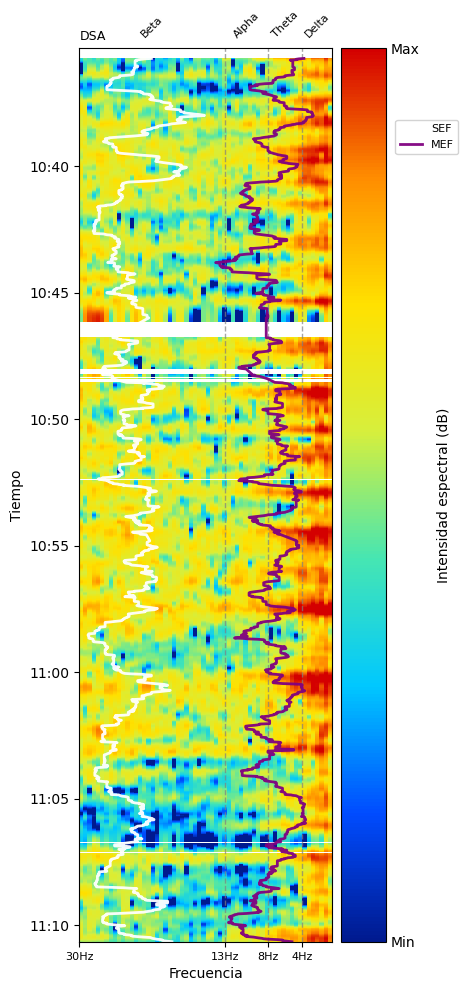

In [12]:
df_merge_vertical = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_vertical = df_merge_vertical["SEF08"]
mf_vertical = df_merge_vertical["MEDFRQ08"]

dsa_plot_vertical, mask_total_vertical = fun_dsa.preparar_dsa_para_plot(tiempo_fa_unilat, dsa_unilat, df_merge_vertical)
matriz_vertical, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_vertical)

fun_dsa.plot_dsa_pdf_con_spa(tiempo_fa_unilat, dsa_unilat, df_spa_unilat)

### vista horizontal tipo análisis

In [13]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_para_plot(tiempo_fa_unilat, dsa_unilat, df_merge_hor)
matriz_hor, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor)

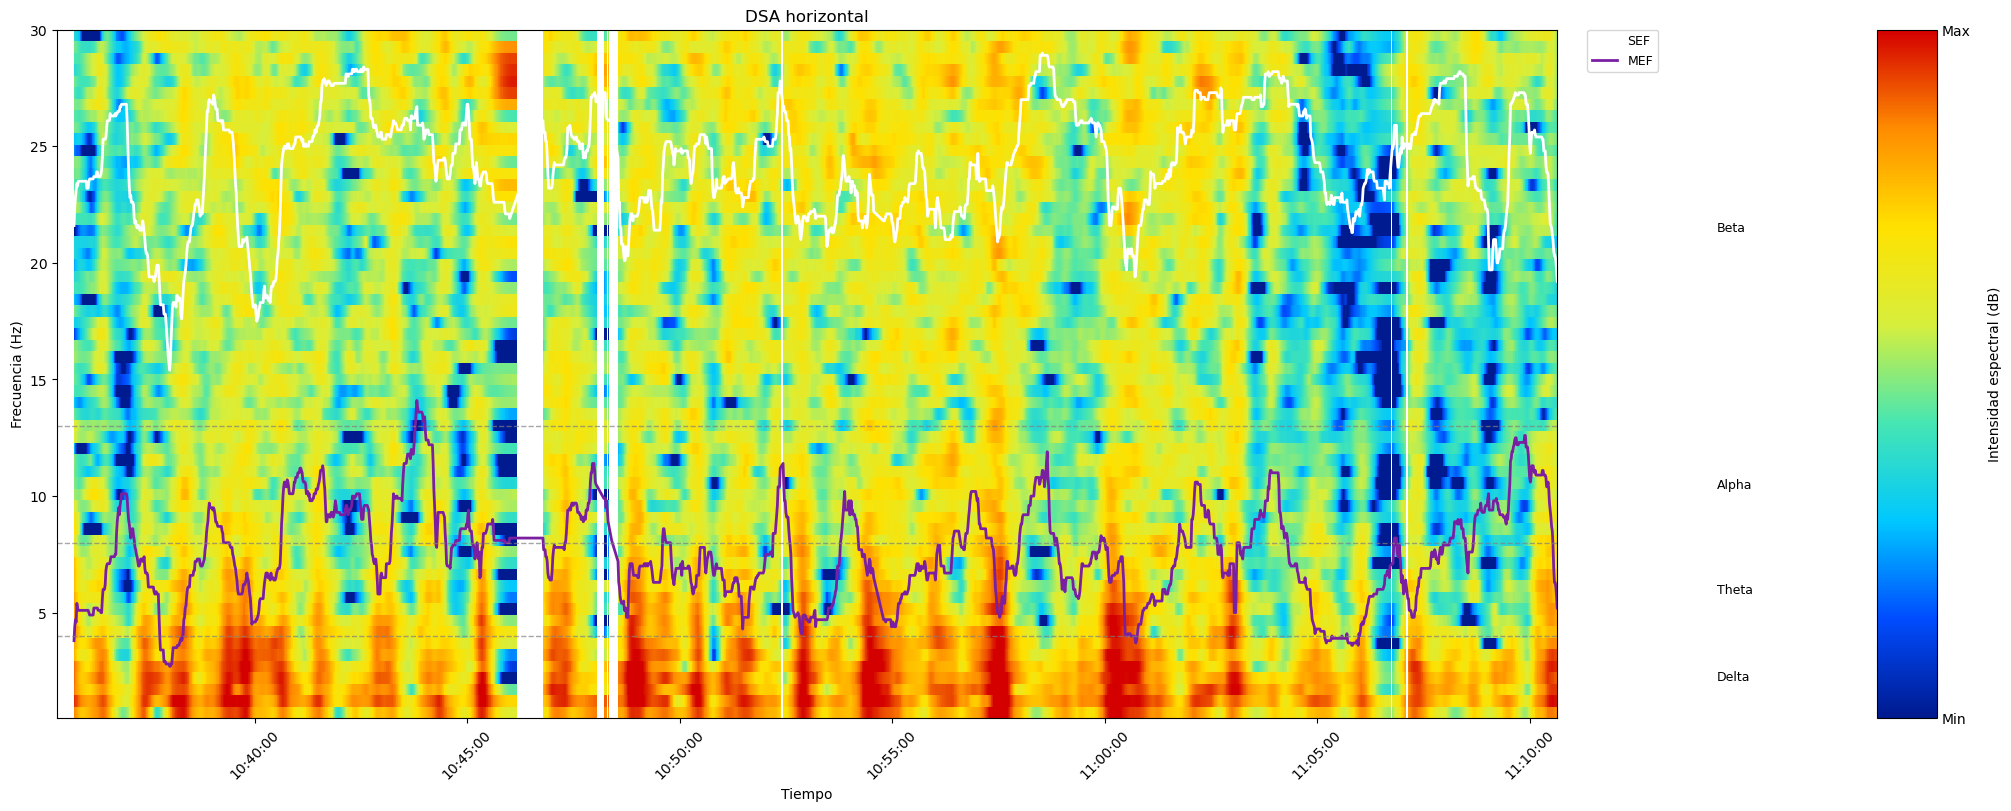

(<Figure size 2000x800 with 3 Axes>,
 <AxesSubplot:title={'center':'DSA horizontal'}, xlabel='Tiempo', ylabel='Frecuencia (Hz)'>,
 <AxesSubplot:>,
 <AxesSubplot:ylabel='Intensidad espectral (dB)'>)

In [14]:
fun_dsa.plot_dsa_horizontal(dsa_plot_hor=dsa_plot_hor, tiempo=tiempo_fa_unilat, sef_hor=sef_hor, mf_hor=mf_hor, titulo="DSA horizontal")

### Unidades del mapa de color

Los valores espectrales están almacenados escalados por un factor 100 y, tras corregirlo, el mapa de color representa potencia espectral en dB.



### Resolución temporal real

La resolución temporal real del archivo .f_a es de 1 segundo por fila.

### Comportamiento de distintas variables a lo largo del tiempo

Para ver qué variables afectan a la pérdida de información o cómo responden a dicha pérdida:
 - SQI10 y TOTPOW08: afectan a la calidad y pérdida de información
 - DB13U01: se ve que se pierde la información
 
 
El análisis conjunto de los archivos .f_a y .spa sugiere que las bandas blancas de la DSA no corresponden simplemente a ausencia de filas en la matriz espectral, sino a tramos que el sistema considera no válidos. 

En los datos analizados, estos tramos coinciden con descensos de SQI10 por debajo de aproximadamente 14 y con la aparición del valor centinela -327.7 en TOTPOW08 y -3276.8 DB13U01, interpretado como valor no válido o no disponible. 

Esta interpretación es coherente con el hecho de que el archivo .spa contiene variables procesadas del sistema y con la definición de la DSA como representación de la potencia EEG mediante color.

In [15]:
"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["SQI10"], errors="coerce"))
plt.title("SQI10 a lo largo del tiempo")
plt.ylabel("SQI10")
plt.xlabel("Tiempo")
plt.show()"""


"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["TOTPOW08"], errors="coerce"))
plt.title("TOTPOW08 a lo largo del tiempo")
plt.ylabel("TOTPOW08")
plt.xlabel("Tiempo")
plt.show()"""


"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["DB13U01"], errors="coerce"))
plt.title("DB13U01 a lo largo del tiempo")
plt.ylabel("DB13U01")
plt.xlabel("Tiempo")
plt.show()"""

'plt.figure(figsize=(12,4))\nplt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["DB13U01"], errors="coerce"))\nplt.title("DB13U01 a lo largo del tiempo")\nplt.ylabel("DB13U01")\nplt.xlabel("Tiempo")\nplt.show()'

### Comprobación de valores de campos pre-limpieza

In [16]:
#resultado_sqi = fau.buscar_filas_por_valor(df_spa_unilat, "TOTPOW08", ">", 30)

In [17]:
#resultado_sqi[["Time", "SQI10", "SQI10_2", "SQI10_3", "TOTPOW08", "TOTPOW08_2", "TOTPOW08_3"]]

In [18]:
#resultado_sqi[["Time", "SQI10", "SQI10_2", "SQI10_3", "EMGLOW01", "EMGLOW01_2", "EMGLOW01_3"]]

In [19]:
#resultado_sqi[["Time", "SQI10", "SQI10_2", "SQI10_3", "DB13U01", "DB13U01_2","DB13U01_3"]]

### Figura compuesta

Construcción de una figura compuesta donde se representan:
 - DSA eh horizontal tipo BIS
 - Las curvas de SEF y MEF superpuestas sobre la matriz
 - Variables procesadas del .spa
 
Todos los gráficos comparten el mismo eje temporal, para que queden alineados.

**Lógica de archivos:** unir información espectral del .f_a con información procesada del .spa en una sola visualización sincronizada.

1. Se construyó una figura compuesta en la que la matriz espectral DSA, reconstruida a partir del archivo .f_a, se representó en formato horizontal, con el tiempo en el eje X y la frecuencia en el eje Y. 

2. Sobre esta representación se superpusieron las curvas de SEF y MEF obtenidas del archivo .spa.

3. Para garantizar la comparabilidad temporal, las variables procesadas del .spa se alinearon con la serie temporal de la DSA mediante una fusión por la columna Time. 

4. Posteriormente, se aplicó una máscara de invalidez para excluir tramos de baja calidad de señal, basada en SQI10 y en valores centinela de TOTPOW08, así como criterios adicionales sobre la propia matriz espectral, como presencia masiva de ceros y discontinuidades temporales.

5. La DSA se representó mediante un mapa de color no lineal, ajustado con PowerNorm, y un colormap personalizado similar al del monitor BIS. 

6. Finalmente, bajo la DSA se añadieron varias señales procesadas (EMGLOW01, BURST, DB13U01), compartiendo el mismo eje temporal, lo que permitió analizar simultáneamente la evolución espectral y el comportamiento de variables clínicas derivadas.

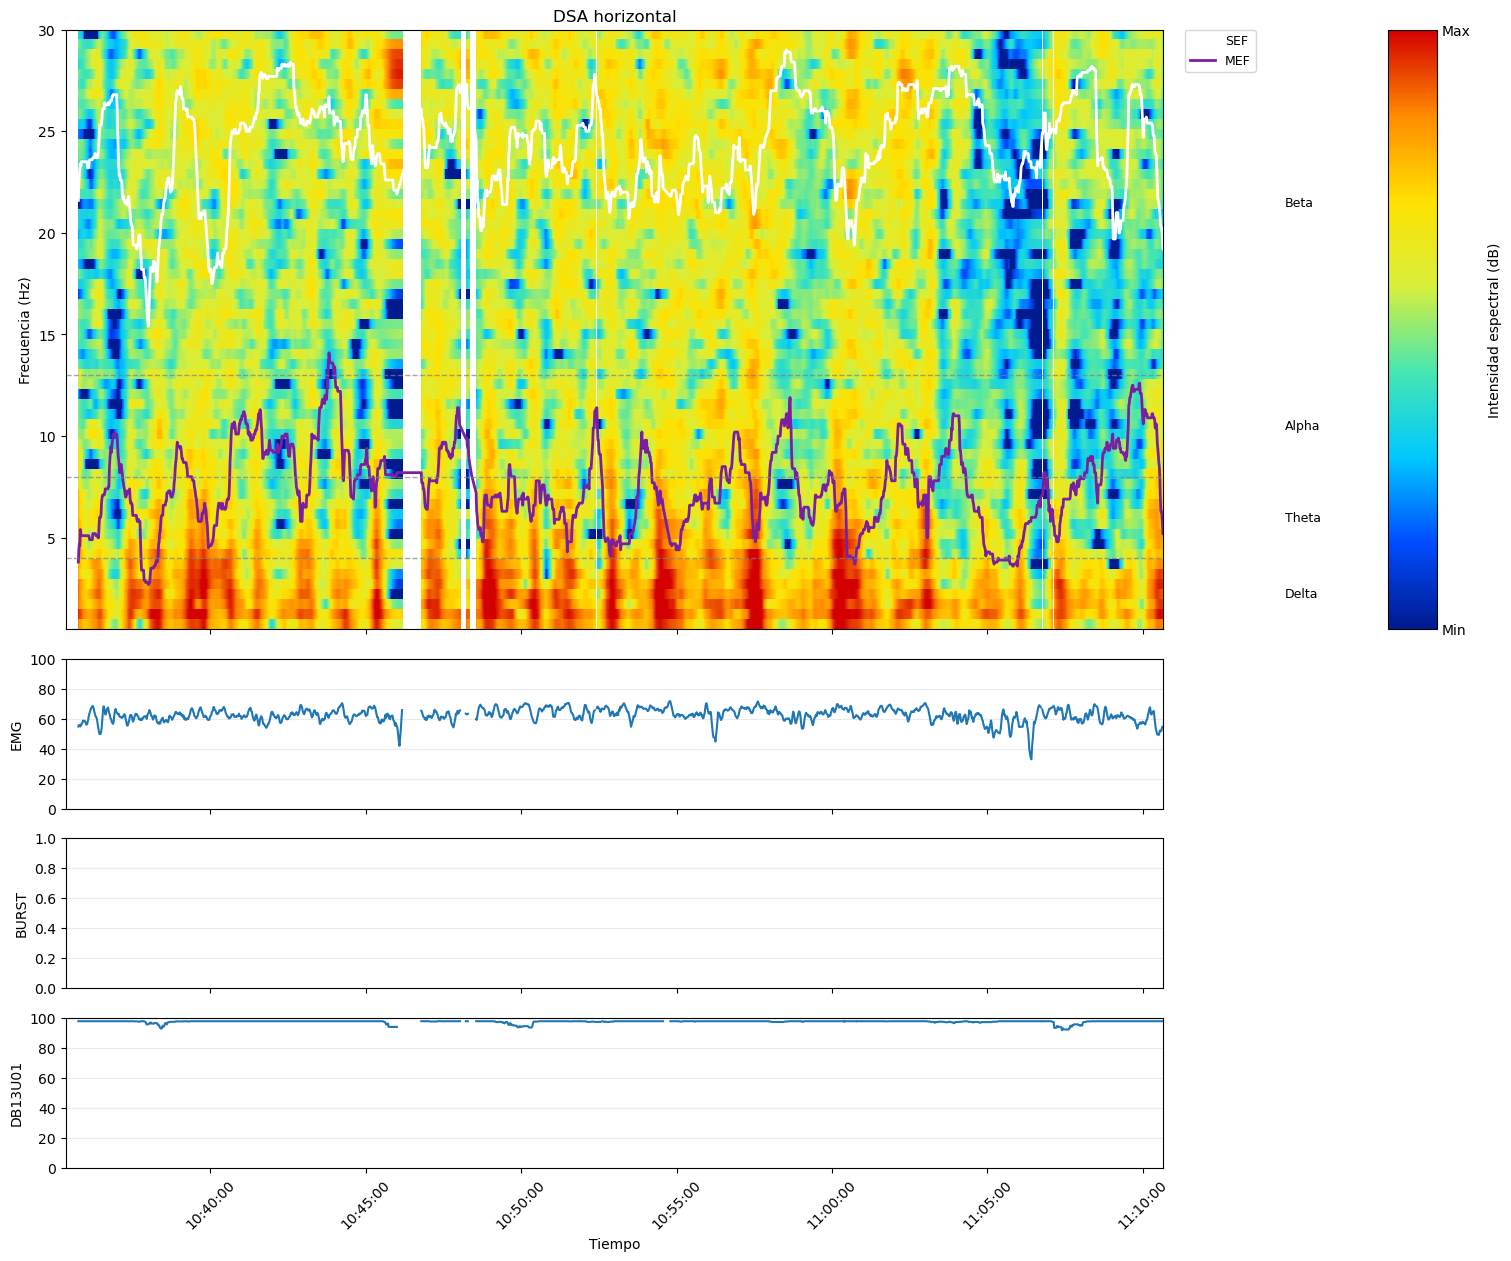

In [20]:
_ = fun_dsa.figura_dsa_y_variables_alineadas(
    tiempo_fa_unilat,
    dsa_unilat,
    df_spa_unilat,
    umbral_sqi=14,
    incluir=("EMGLOW01", "BURST", "DB13U01")
)

## archivo r2a

El archivo .r2a contiene la señal EEG cruda en formato binario con estructura intercalada.

 - es un archivo de 2 canales
 - los datos están guardados de forma intercalada
 - cada valor ocupa 16 bits = 2 bytes
 - los valores son enteros con signo

Eso significa que cada instante temporal del registro se guarda así:

 - 2 bytes: canal 1
 - 2 bytes: canal 2

En total: 4 bytes por frame temporal



En registros de 2 canales, cada instante temporal está formado por dos enteros consecutivos de 16 bits con signo: primero el valor del canal 1 y después el del canal 2. Por tanto, cada frame ocupa 4 bytes. 


In [21]:
archivos_r2a = glob.glob(os.path.join(ruta_base_advanced, "**", "*.r2a"), recursive=True)

In [22]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

""" 
"rb" = lectura en modo binario
read(32) = leer los primeros 32 bytes del archivo
"""

with open(archivo_r2a, "rb") as archivo:
    primeros_bytes = archivo.read(32)

print("Datos en bruto (Hexadecimal):")
print(primeros_bytes.hex(' '))

Datos en bruto (Hexadecimal):
42 f4 ce f3 f2 f3 cb f2 27 f5 24 f4 69 f4 d6 f4 1e f4 0a f4 46 f4 43 f4 d4 f4 d8 f3 db f5 6e f3


### Interpretación de los datos en bruto

Como cada frame temporal ocupa 4 bytes, esos 32 bytes contienen: 32/4=8 frames. 8 instantes temporales.

Cada frame se divide así:
 - bytes 1–2 → canal 1
 - bytes 3–4 → canal 2
 
Ejemplo de los datos en bruto:

1. Frame 1: 42 f4 | ce f3
    - Canal 1 = 42 f4
    - Canal 2 = ce f3
    
    
2. Frame 2: f2 f3 | cb f2
    - Canal 1 = f2 f3
    - Canal 2 = cb f2


3. Frame 3: 27 f5 | 24 f4
    - Canal 1 = 27 f5
    - Canal 2 = 24 f4
    

Por tanto, el archivo contiene frames de muestreo de 2 canales entrelazados, no guarda primero todo el canal 1 y luego todo el canal 2.
 - Patrón: C1, C2, C1, C2, C1, C2...


In [23]:
# meter la "r" antes para que lea la ruta tal cual por si hay caracteres especiales
archivo_entrada = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"
archivo_salida = "voltajes_cerebrales_final_nuevos.csv"

In [24]:
fau.traducir_r2a(archivo_entrada, archivo_salida)

Se procesaron 271312 muestras por canal.
Tiempo total real: 2119.62 segundos.


### Frecuencia de muestreo

El módulo genera 256 muestras/s en total, al ser un archivo de 2 canales, eso equivale a 128 muestras/s por canal. 

Esto no está especificado como tal en los manuales pero es la conclusión obtenida tras la recopilación de la información disponible


### Comprobación con el número de muestras

Si divides 271312/128 = 2119.625 s. Coincide con la duración calculada.

En este archivo hay 271312 frames y cada uno contiene 1 muestra de canal 1 y 1 muestra de canal 2.

In [25]:

def explicar_frames_r2a(ruta_r2a, n_frames=8, factor_uv=0.05, mostrar=True):
    """
    Lee los primeros n_frames de un archivo .r2a y:
    - separa los frames de 4 bytes
    - divide cada frame en canal 1 y canal 2
    - traduce cada pareja de bytes a entero con signo de 16 bits
    - convierte los valores a microvoltios
    
    Devuelve un DataFrame con el detalle.
    """

    """ 
    "rb" = lectura en modo binario
    read(n_frames * 4) = leer los primeros 32 bytes del archivo
    """
    with open(ruta_r2a, "rb") as f:
        bruto = f.read(n_frames * 4)

        
    # lista vacía en la que se guardan las filas (diccionarios con las características de los frames)
    filas = []

    if mostrar:
        print("ANÁLISIS DEL ARCHIVO .r2a")
        print("-" * 60)
        print(f"Se leen los primeros {n_frames * 4} bytes del archivo.")
        print("Cada frame temporal ocupa 4 bytes:")
        print("  - 2 bytes para el canal 1")
        print("  - 2 bytes para el canal 2")
        print(f"Conversión a microvoltios: valor_crudo × {factor_uv}")
        print()
        
    
    """
    recorrer los frames desde 0 a n-1
    bloque: se cogen los 4 bytes de cada frame. Si se lee que el bloque es más pequeño que eso se detiene
            del bloque principal se divide en 2 sub-bloques uno por cada canal
    """
    for i in range(n_frames):
        bloque = bruto[i*4:(i+1)*4]

        if len(bloque) < 4:
            break

        bytes_c1 = bloque[:2]
        bytes_c2 = bloque[2:]

        
        """        
        Interpreta cada pareja de bytes como un entero con signo de 16 bits
        struct.unpack("<h", bytes_c1):
            h: entero corto con signo, 16 bits, 2 bytes
            <: little-endian
            [0]: porque struct.unpack(...) devuelve una tupla y hay que quedarse con el primer elemento
        """        
        raw_c1 = struct.unpack("<h", bytes_c1)[0]
        raw_c2 = struct.unpack("<h", bytes_c2)[0]

        """ 
        Fórmula de procesamiento: 
        Para obtener la amplitud real de la onda cerebral, debes coger el número entero extraído y multiplicarlo por 0.05. 
        El resultado será el valor de la onda en microvoltios (µV).
        """
        uv_c1 = raw_c1 * factor_uv
        uv_c2 = raw_c2 * factor_uv

        # crea un diccionario con toda la información útil del frame actual
        fila = {
            "Frame": i + 1,
            "Bytes frame": bloque.hex(" "),
            "Bytes C1": bytes_c1.hex(" "),
            "Bytes C2": bytes_c2.hex(" "),
            "Raw C1": raw_c1,
            "Raw C2": raw_c2,
            "C1 (µV)": uv_c1,
            "C2 (µV)": uv_c2,
        }
        filas.append(fila)

        if mostrar:
            print(f"Frame {i+1}")
            print(f"  Bytes del frame: {bloque.hex(' ')}")
            print(f"  Canal 1 -> bytes: {bytes_c1.hex(' ')} -> entero: {raw_c1} -> µV: {uv_c1:.2f}")
            print(f"  Canal 2 -> bytes: {bytes_c2.hex(' ')} -> entero: {raw_c2} -> µV: {uv_c2:.2f}")
            print()

    """
    convierte la lista de diccionarios en un DataFrame de pandas
    cada diccionario será una fila
    """
    df_frames = pd.DataFrame(filas)
    return df_frames

In [26]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

df_frames_r2a = explicar_frames_r2a(ruta_r2a=archivo_r2a, n_frames=8, factor_uv=0.05, mostrar=False)

display(df_frames_r2a)

,Frame,Bytes frame,Bytes C1,Bytes C2,Raw C1,Raw C2,C1 (µV),C2 (µV)
0,1,42 f4 ce f3,42 f4,ce f3,-3006,-3122,-150.30,-156.10
1,2,f2 f3 cb f2,f2 f3,cb f2,-3086,-3381,-154.30,-169.05
2,3,27 f5 24 f4,27 f5,24 f4,-2777,-3036,-138.85,-151.80
3,4,69 f4 d6 f4,69 f4,d6 f4,-2967,-2858,-148.35,-142.90
4,5,1e f4 0a f4,1e f4,0a f4,-3042,-3062,-152.10,-153.10
5,6,46 f4 43 f4,46 f4,43 f4,-3002,-3005,-150.10,-150.25
6,7,d4 f4 d8 f3,d4 f4,d8 f3,-2860,-3112,-143.00,-155.60
7,8,db f5 6e f3,db f5,6e f3,-2597,-3218,-129.85,-160.90


**Conversión a Microvoltios (La escala)**

 - El número entero que se lee del archivo no es el voltaje directo. Se especifica que los valores están en unidades de 0.05 µV.
 - Fórmula de procesamiento: Para obtener la amplitud real de la onda cerebral, debes coger el número entero extraído y multiplicarlo por 0.05. El resultado será el valor de la onda en microvoltios (µV).
 

**Manejo de errores o "huecos"**

 - Si se pierden paquetes de datos, el equipo mantiene la sincronización temporal del archivo rellenando ese hueco con datos de amplitud cero (0).

## Representación de las ondas crudas

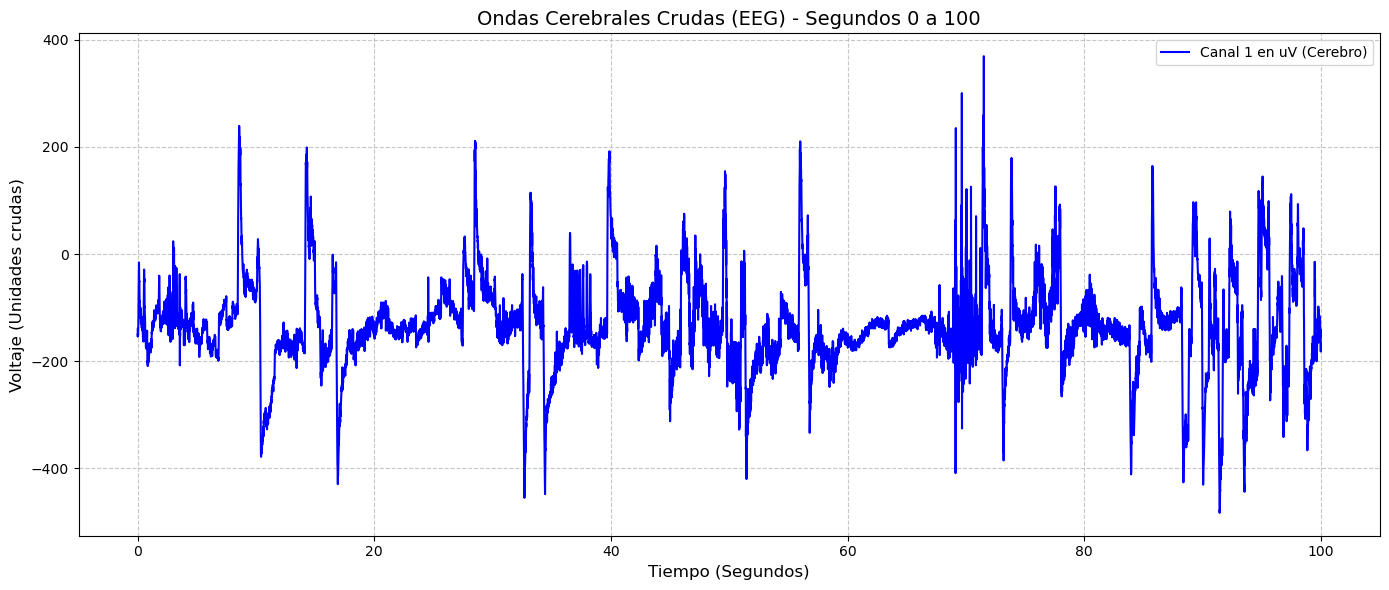

In [27]:

# Cargar archivo CSV
df = pd.read_csv("voltajes_cerebrales_final_nuevos.csv")

# Elegir ventana de tiempo 
t_inicio = 0
t_fin = 100

# Filtramos los datos para coger solo la ventana
df_ventana = df[(df['Tiempo_s'] >= t_inicio) & (df['Tiempo_s'] <= t_fin)]

# crear tamaño figura
plt.figure(figsize=(14, 6))

# dibujar la línea del Canal 1 (cerebro real)
plt.plot(df_ventana['Tiempo_s'], df_ventana['Canal_1_uV'], color='blue', linewidth=1.5, label='Canal 1 en uV (Cerebro)')

# títulos, etiquetas y cuadrícula
plt.title(f'Ondas Cerebrales Crudas (EEG) - Segundos {t_inicio} a {t_fin}', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel('Voltaje (Unidades crudas)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Guardar la imagen
plt.tight_layout()
# plt.savefig(f'mis_ondas_eeg_{t_inicio}_a_{t_fin}.png', dpi=300)
plt.show()


## Reconstrucción de DSA a partir de ondas crudas

La matriz de Densidad Espectral se reconstruyó a partir del EEG crudo mediante un análisis tiempo-frecuencia por ventanas.

La señal, registrada a 128 Hz y expresada en microvoltios, se segmentó en ventanas solapadas de 2 segundos con avance de 1 segundo.
 - Segmentación en ventanas de 2 segundos: 
     - Frecuencia de muestreo: el monitor toma 128 muestras por segundo, una muestra cada 0.0078125 segundos
     - La resolución frecuencial viene dada aproximadamente por resolución = fs / nfft
     - Resolución frecuencial: separación entre las frecuencias que se distinguen ene el espectro calculado (1/duración de la ventana)
     - 128 / 256 = 0.5 Hz 
     - Al tener 256 muestras a 128 Hz, 256 / 128 = 2 segundos de ventana
 - Avance de 1 segundo: cada cuánto se desplaza la ventana para calcular la siguiente fila de la DSA

Para cada ventana se eliminó la componente continua, se aplicó una ventana de Hann y se estimó la potencia espectral mediante FFT/WELCH.
 - **Eliminar la componente continua:** quitar de cada ventana el valor medio de la señal antes de calcular el espectro.
     -  Antes del cálculo espectral se eliminó la componente continua de cada ventana mediante la resta de su media local. 
     - Esta operación evita que los desplazamientos de línea base de la señal EEG, asociados a componentes de 0 Hz o muy baja frecuencia, dominen la estimación espectral. De este modo, la DSA representa principalmente la actividad oscilatoria de la señal y no el offset eléctrico del registro.
 - **Ventana de Hann:** La ventana de Hann reduce el peso de los extremos del fragmento y da más peso al centro.
     - Antes de aplicar la transformada de Fourier, cada segmento de EEG se multiplicó por una ventana de Hann. 
     - Esta ventana reduce progresivamente el peso de las muestras situadas en los extremos del segmento, minimizando las discontinuidades artificiales producidas por el corte temporal de la señal. 
     - De este modo se reduce la fuga espectral y se obtiene una estimación más estable de la potencia asociada a cada frecuencia.
 - **Estimar la potencia espectral:** Cuantificar la distribución de la energía o potencia de una señal en función de la frecuencia.
     - Se aplica a ventanas temporales de EEG para obtener, en cada instante, la contribución relativa de las distintas componentes frecuenciales entre 0.5 y 30 Hz.
     - El resultado es una matriz tiempo-frecuencia en la que cada valor representa la potencia asociada a una frecuencia concreta durante una ventana temporal determinada.
 - **FFT/Welch:** El método FFT/Welch es un procedimiento utilizado para estimar la potencia espectral de una señal.
     - La FFT permite transformar cada segmento temporal del EEG al dominio de la frecuencia, descomponiéndolo en componentes sinusoidales.
     - El método de Welch aplica esta transformación sobre segmentos de señal previamente acondicionados mediante eliminación de la media y ventana de Hann, obteniendo una estimación más estable del espectro de potencia. 
 
 
**Procedimiento FFT/WELCH:** 
 - x(t) = señal EEG en µV
 - Hay 128 muestras por segundo. Para cada cálculo cogemos una ventana de 2 segundos. 2 s × 128 muestras/s = 256 muestras.
 - Antes de calcular frecuencias, se resta la media de la ventana: x_centrada = x - media(x)
     - Esto elimina la componente continua, es decir, el desplazamiento de línea base. detrend="constant"
 - Después, la señal de la ventana se multiplica por una ventana de Hann: x_hann[n] = x_centrada[n] · w[n]
     - w[n] vale poco en los extremos y más en el centro.
     - Evitar que el corte brusco del fragmento introduzca artefactos en el espectro
     - window="hann"
 - La FFT transforma la señal desde el dominio temporal al dominio de la frecuencia. Descompone el EEG en una suma de ondas simples.
 - A partir d e los coeficientes de la FFT se calcula la potencia. La potencia está relacionada con el módulo al cuadrado del coeficiente frecuencial:
     - potencia(f) ∝ |FFT(f)|²
     - lo hace internamente welch() y devuelve: f, pxx. Donde f = frecuencias y pxx = potencia estimada para cada frecuencia


Welch frente a una FFT directa:
Una FFT directa sobre una ventana de EEG generalmente coge la muestra y calcula directamente cuánta potencia hay en cada frecuencia. Da un espectro para esa ventana.

Por otro lado, el método Welch, en lugar de calcular una sola FFT sobre un fragmento grande, divide ese fragmento en subfragmentos más pequeños, calcula un espectro para cada uno y luego los promedia.

En esta implementación ya se dividía el EEG manualmente en ventanas de 2 segundos e internamente se llama a welch, usando el parámetro nperseg = 256. 
Así, Welch no puede dividir ese segmento en varias subventanas, porque el segmento entero ya mide exactamente 256 muestras. Por ello, Welch se comporta casi como una FFT directa preparada, porque no está promediando varias subventanas internas. 

Aunque en esta configuración no aproveches toda la parte de “promediar subventanas” de Welch, welch() sigue siendo útil porque te hace de forma ordenada y consistente varias cosas:
1. elimina la media de la ventana con detrend="constant"
2. aplica la ventana Hann
3. calcula la FFT
4. calcula la potencia espectral
5. devuelve las frecuencias correctamente
6. aplica el escalado elegido


**Resumen:**
Aunque se empleó la función welch() de SciPy, en esta implementación cada llamada se aplicó sobre una ventana temporal de 2 segundos, coincidiendo la longitud del segmento con nperseg. Por tanto, no se realizó un promediado interno de múltiples subsegmentos, como en el método Welch clásico, sino que la función se utilizó principalmente para aplicar de forma controlada el preprocesamiento espectral: eliminación de la media, ventana de Hann, cálculo de la FFT, estimación de potencia y escalado. Esta configuración permite obtener una estimación espectral local cada segundo, manteniendo una resolución frecuencial de 0.5 Hz.

### Explicación de la TTF
La Transformada Discreta de Fourier (DFT), calculada de forma eficiente mediante la FFT, transforma una señal temporal discreta (x[n]) en sus componentes frecuenciales (X[k]). 

La fórmula significa: Para calcular cuánto hay de la frecuencia k, se compara toda la señal temporal x[n] con una onda compleja de esa frecuencia.

$$
X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j 2\pi kn/N}
$$


donde:

- \(x[n]\) amplitud EEG en la muestra n en microvoltios (x[0],x[1],x[2],…,x[255]).
- \(n\) es el índice de muestra temporal [0, 1, 2, ...].
- \(N\) número de puntos de la ventana analizada (256).
- \(k\) índice de frecuencia [0, 1, 2, ...].
- \(X[k]\) resultado de aplicar la FFT a x[n], es la señal en frecuencia. Se compone de:
    - parte real: amplitud -> cuánto hay de esa frecuencia
    - parte imaginaria: fase -> en qué punto de la onda está
- \(j\) es la unidad imaginaria.

La frecuencia real asociada a cada índice \(k\) se calcula como:

$$
f_k = \frac{k f_s}{N} 
$$

donde:

- \(f_k\) es la frecuencia en Hz correspondiente al índice \(k\) [0 Hz, 0.5Hz, 1, ...].
- \(f_s\) es la frecuencia de muestreo de la señal.
- \(N\) es el número de puntos de la FFT.


En este trabajo, la señal EEG se encuentra muestreada a:

$$
f_s = 128 \ \text{Hz}
$$

y cada ventana temporal tiene una duración de 2 segundos. Por tanto, cada ventana contiene:

$$
N = 2 \cdot 128 = 256 \ \text{muestras}
$$

La resolución frecuencial viene dada por:

$$
\Delta f = \frac{f_s}{N}
$$

Sustituyendo los valores utilizados:

$$
\Delta f = \frac{128}{256} = 0.5 \ \text{Hz}
$$

Esto significa que la FFT proporciona componentes frecuenciales separadas cada \(0.5\) Hz:

$$
0,\ 0.5,\ 1.0,\ 1.5,\ 2.0,\ \ldots,\ 64 \ \text{Hz}
$$

Para la construcción de la DSA se seleccionó únicamente el rango de interés entre \(0.5\) y \(30\) Hz:

$$
0.5 \ \text{Hz} \leq f \leq 30 \ \text{Hz}
$$

A partir de los coeficientes complejos de la FFT se estima la potencia asociada a cada frecuencia mediante el módulo al cuadrado:

$$
P[k] = |X[k]|^2
$$

donde \(P[k]\) representa la potencia espectral asociada a la frecuencia correspondiente al índice \(k\).

Finalmente, para facilitar la representación visual de la DSA, la potencia se transforma a escala logarítmica en decibelios:

$$
P_{dB}[k] = 10 \log_{10}(P[k])
$$

Conversión de la potencia a decibelios
 - La potencia puede tener un rango muy amplio. Para representarla mejor en la DSA, se transforma a escala logarítmica: potencia_dB = 10 · log10(potencia)
 - valores = 10 * np.log10(pxx_sel + 1e-12)
 - La escala dB comprime valores muy grandes y muy pequeños, haciendo que los patrones espectrales sean más visibles en el mapa de color.

Guardado de una fila de la DSA
 - Para cada ventana se obtiene un vector de 60 valores: 0.5 Hz, 1.0 Hz, 1.5 Hz, ..., 30.0 Hz
 - Ese vector se guarda como una fila: tiempo | 0.5_Hz | 1.0_Hz | 1.5_Hz | ... | 30.0_Hz
 - Luego la ventana avanza 1 segundo y se repite el proceso. 
 - La matriz final queda:
      - filas    = tiempo
      - columnas = frecuencias
      - valores  = potencia espectral en dB

Se conservaron las frecuencias entre 0.5 y 30 Hz con una resolución de 0.5 Hz, transformando la potencia a decibelios para su representación.
 - Solo se seleccionan las frec entre 0.5 y 30 Hz de 0.5 en 0.5 Hz comp en el archivo .f_a

La matriz se visualiza como una DSA, aplicando una escala cromática tipo BIS y enmascatando en blanco los periodos de mala calidad o pérdida de información identificados mediante variables del archivo .spa.
 - Cada punto de la DSA significa que, entorno a este instante temporal, dentro de una ventana corta de EEG, la señal contiene esta cantidad de potencia asociada a esta frecuencia. No significa que el cerebro esté generando una única frecuencia exacta, sino que esa frecuencia forma parte de la descomposición espectral de la señal.

tiempo:      0 s      1 s      2 s      3 s      4 s      5 s
             |-------- ventana 1 --------|
                      |-------- ventana 2 --------|
                               |-------- ventana 3 --------|
                                        |-------- ventana 4 --------|
                                        
                                        
     
1 segundo son 128 muestras:

ventana 1: muestras 0 a 255      → 0 s a 2 s
ventana 2: muestras 128 a 383    → 1 s a 3 s
ventana 3: muestras 256 a 511    → 2 s a 4 s
ventana 4: muestras 384 a 639    → 3 s a 5 s
...

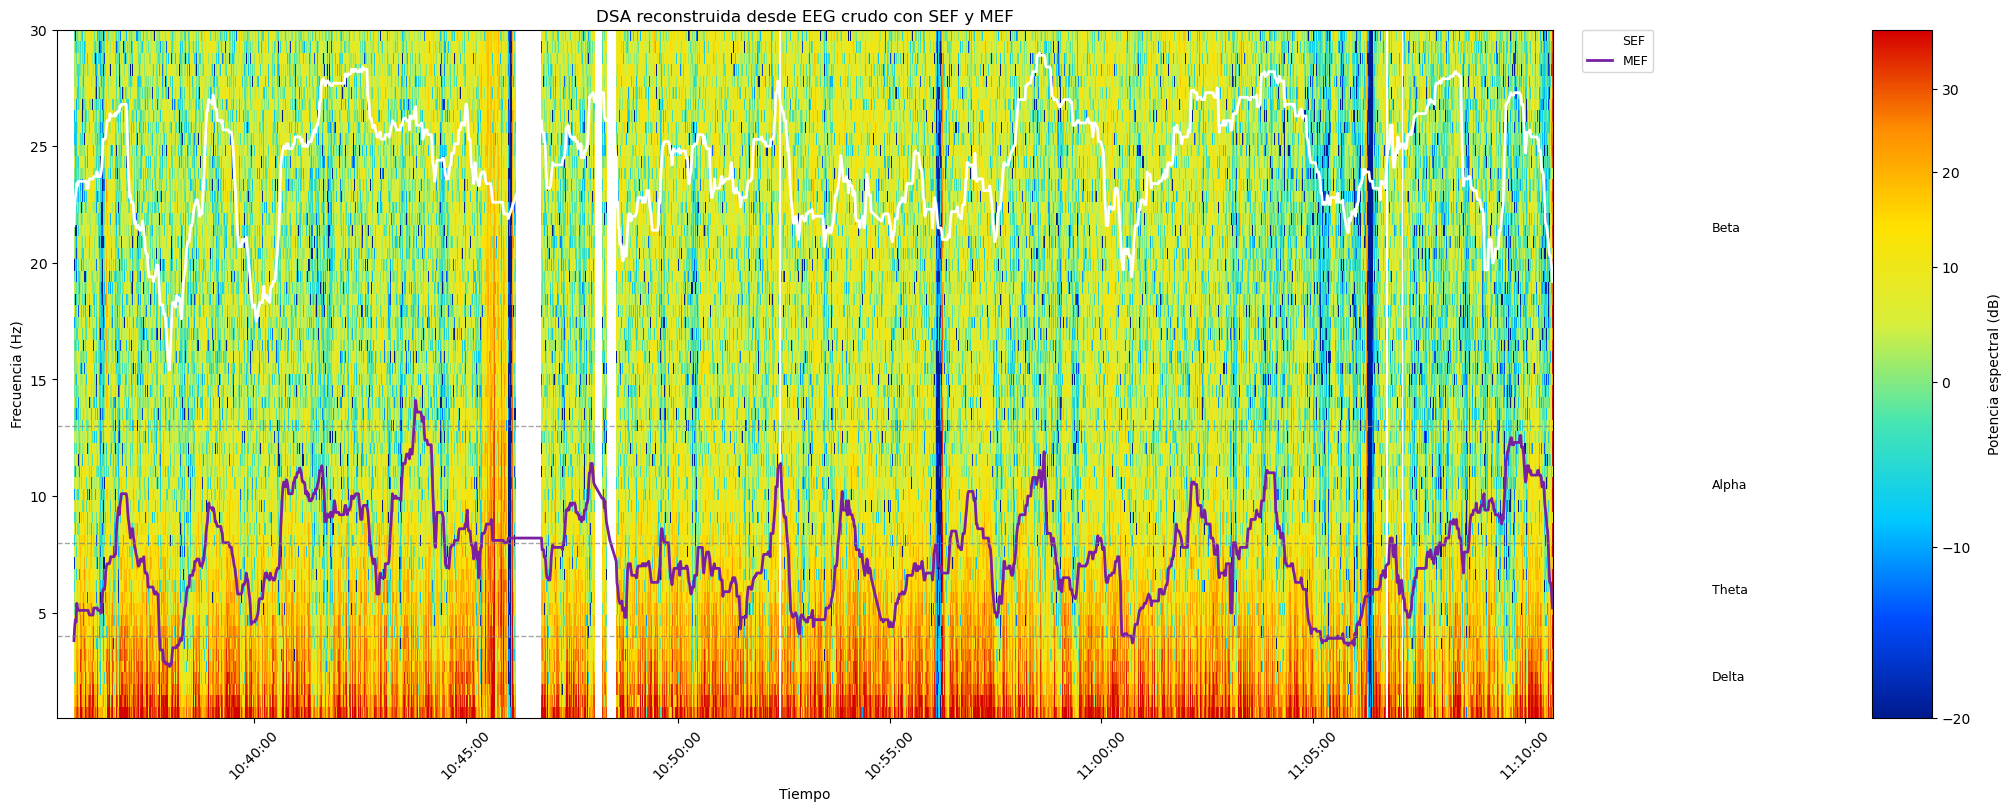

In [28]:
# 1. Leer EEG crudo
df_eeg = fun_dsa.leer_r2a(
    archivo_r2a,
    fs=128,
    escala_uv=0.0511
)

# 2. Crear matriz DSA mediante FFT/Welch
df_dsa, frecuencias = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg,
    fs=128,
    canal="canal_1_uV",
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="db",
    tiempo_referencia="centro"
)

# 3. Asegurar que el .spa tiene Time como datetime

df_spa_unilat, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(df_spa_unilat)

# 4. Adaptar al formato esperado por tus funciones
tiempo_eeg, dsa_eeg = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa,
    frecuencias=frecuencias,
    hora_inicio=hora_inicio,
    insertar_fila_inicial_nan=True
)

# 5. Alinear SPA con tiempos de la DSA
df_merge_plot = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo_eeg,
    df_spa=df_spa_unilat
)

# 6. Preparar DSA con máscaras blancas
dsa_plot, mask_total = fun_dsa.preparar_dsa_para_plot(
    tiempo=tiempo_eeg,
    dsa=dsa_eeg,
    df_merge=df_merge_plot,
    umbral_sqi=14,
    umbral_ceros=0.9
)

# 7. Preparar escala de color tipo BIS
matriz_eeg, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(
    dsa_plot,
    gamma=0.55
)

# 6. Dibujar DSA con SEF y MEF
fig, ax, ax_band, cax = fun_dsa.plot_dsa_con_sef_mef(
    tiempo=tiempo_eeg,
    frecuencias=frecuencias,
    matriz=matriz_eeg,
    norm=norm,
    cmap=cmap,
    df_merge=df_merge_plot,
    titulo="DSA reconstruida desde EEG crudo con SEF y MEF"
)

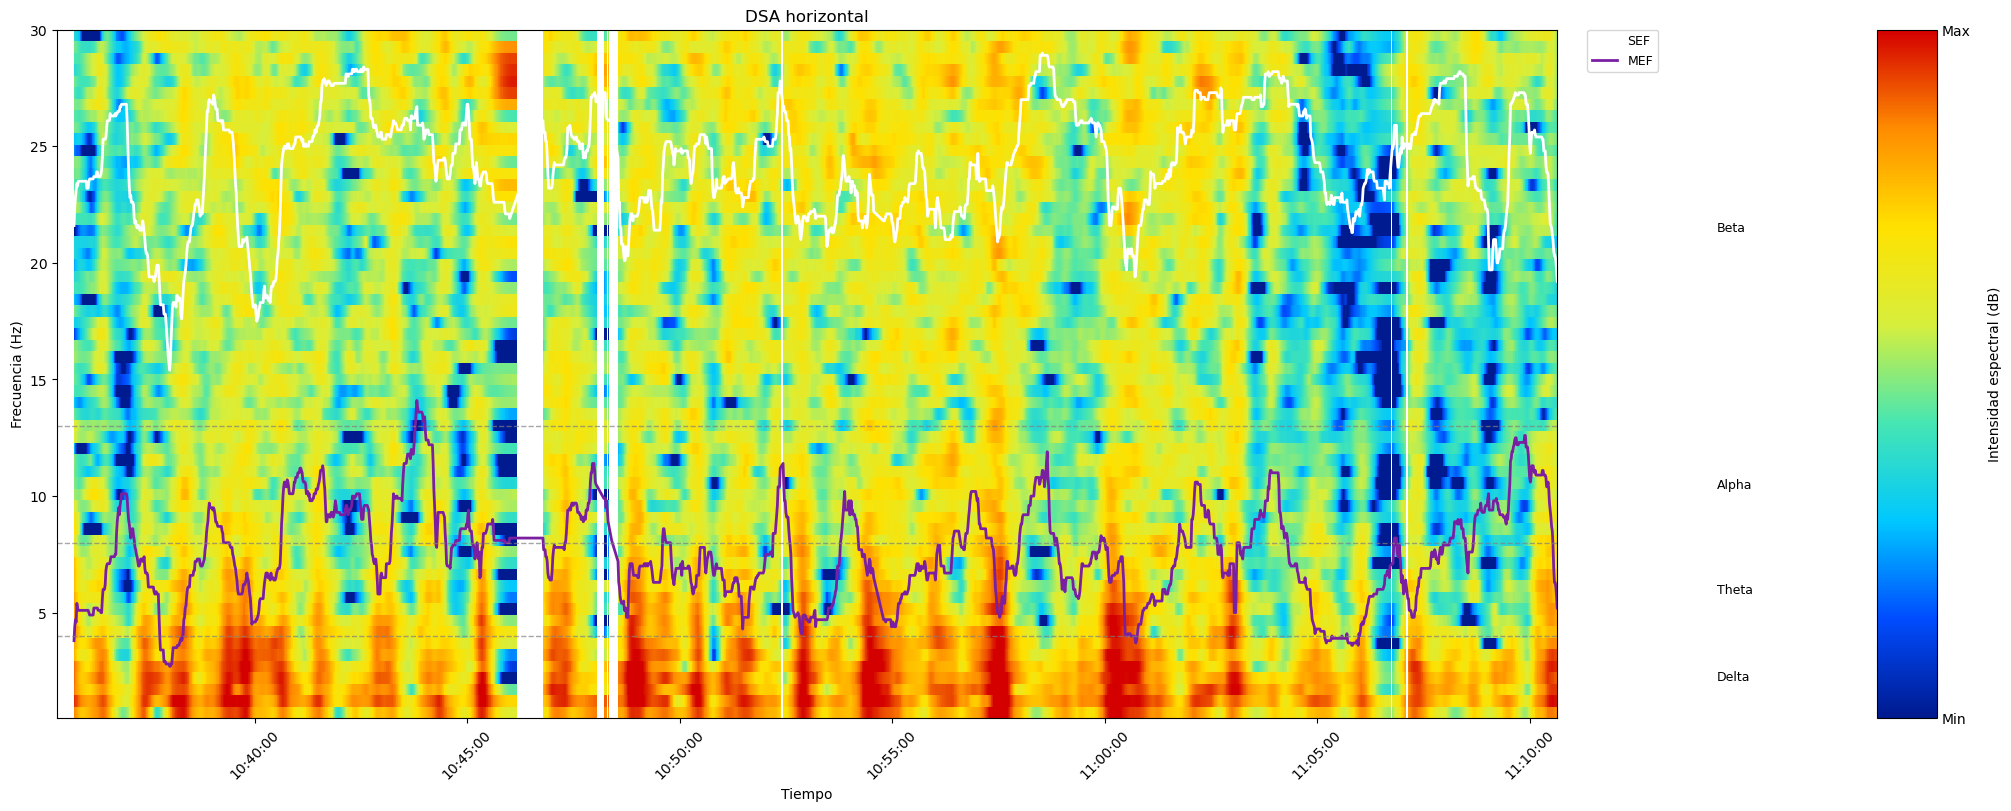

(<Figure size 2000x800 with 3 Axes>,
 <AxesSubplot:title={'center':'DSA horizontal'}, xlabel='Tiempo', ylabel='Frecuencia (Hz)'>,
 <AxesSubplot:>,
 <AxesSubplot:ylabel='Intensidad espectral (dB)'>)

In [29]:
df_merge_hor = fun_dsa.alinear_spa_con_tiempo(tiempo_fa_unilat, df_spa_unilat)
sef_hor = df_merge_hor["SEF08"]
mf_hor = df_merge_hor["MEDFRQ08"]

dsa_plot_hor, mask_total_hor = fun_dsa.preparar_dsa_para_plot(tiempo_fa_unilat, dsa_unilat, df_merge_hor)
matriz_hor, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa(dsa_plot_hor)
fun_dsa.plot_dsa_horizontal(dsa_plot_hor=dsa_plot_hor, tiempo=tiempo_fa_unilat, sef_hor=sef_hor, mf_hor=mf_hor, titulo="DSA horizontal")

## Comparación de DSA

Las dos matrices deben tener los nombres de las columnas iguales.

Las dos deben tener la misma longitud y mismas columnas.

Como una matriz tiene más filas iniciales con NaN que la otra, hay que comparar solo donde ambas tienen datos válidos.

In [30]:
print(dsa_plot)
print(dsa_plot_hor)

            0.5        1.0        1.5        2.0        2.5        3.0  \
0           NaN        NaN        NaN        NaN        NaN        NaN   
1           NaN        NaN        NaN        NaN        NaN        NaN   
2           NaN        NaN        NaN        NaN        NaN        NaN   
3           NaN        NaN        NaN        NaN        NaN        NaN   
4           NaN        NaN        NaN        NaN        NaN        NaN   
...         ...        ...        ...        ...        ...        ...   
2114  29.041132  16.037083  21.183186  18.967127  16.752709  15.839537   
2115  31.730948  31.700220  23.444904  24.484730  10.882278  26.935569   
2116  32.356471  27.598173   9.542604  24.820776  24.364969  16.898934   
2117  28.862726  33.516527  27.274560  28.927265   7.061532  28.363155   
2118  26.116400  31.917235  40.130586  41.077070  36.936863  26.788716   

            3.5        4.0        4.5        5.0  ...       25.5       26.0  \
0           NaN        NaN      

In [35]:

def preparar_matrices_para_comparacion(dsa_1, dsa_2):
    """
    Asegura que las dos DSA tengan:
    - mismas columnas
    - misma longitud
    - columnas en el mismo orden
    """

    dsa_1 = dsa_1.copy()
    dsa_2 = dsa_2.copy()

    # Convertir nombres de columnas a float para evitar diferencias tipo "0.5" vs 0.5
    dsa_1.columns = [float(c) for c in dsa_1.columns]
    dsa_2.columns = [float(c) for c in dsa_2.columns]

    columnas_comunes = sorted(set(dsa_1.columns).intersection(set(dsa_2.columns)))

    n = min(len(dsa_1), len(dsa_2))

    dsa_1 = dsa_1.iloc[:n][columnas_comunes]
    dsa_2 = dsa_2.iloc[:n][columnas_comunes]

    return dsa_1, dsa_2


def zscore_global(df):
    """
    Normaliza toda la matriz con media y desviación típica global,
    ignorando NaN.
    """
    matriz = df.to_numpy(dtype=float)

    media = np.nanmean(matriz)
    std = np.nanstd(matriz)

    matriz_z = (matriz - media) / std

    return pd.DataFrame(
        matriz_z,
        index=df.index,
        columns=df.columns
    )


def comparar_dsa_global(dsa_1, dsa_2):
    """
    Calcula métricas globales entre dos matrices DSA.
    Compara solo posiciones donde ambas matrices tienen valores válidos.
    """

    A = dsa_1.to_numpy(dtype=float)
    B = dsa_2.to_numpy(dtype=float)

    mask = np.isfinite(A) & np.isfinite(B)

    A_valid = A[mask]
    B_valid = B[mask]

    if len(A_valid) == 0:
        raise ValueError("No hay valores válidos comunes para comparar.")

    mae = np.mean(np.abs(A_valid - B_valid))
    rmse = np.sqrt(np.mean((A_valid - B_valid) ** 2))
    bias = np.mean(B_valid - A_valid)

    pearson = pearsonr(A_valid, B_valid)[0]
    spearman = spearmanr(A_valid, B_valid)[0]

    return {
        "n_valores_comparados": len(A_valid),
        "MAE": mae,
        "RMSE": rmse,
        "bias_B_menos_A": bias,
        "Pearson": pearson,
        "Spearman": spearman
    }


def correlacion_por_frecuencia(dsa_1, dsa_2):
    """
    Calcula la correlación entre ambas DSA para cada frecuencia.
    """

    resultados = []

    for col in dsa_1.columns:
        a = dsa_1[col].to_numpy(dtype=float)
        b = dsa_2[col].to_numpy(dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)

        if mask.sum() > 2:
            r = pearsonr(a[mask], b[mask])[0]
        else:
            r = np.nan

        resultados.append({
            "frecuencia_Hz": col,
            "correlacion": r
        })

    return pd.DataFrame(resultados)


def correlacion_por_tiempo(dsa_1, dsa_2, tiempo=None):
    """
    Calcula la correlación fila a fila.
    Cada fila representa un instante temporal.
    """

    resultados = []

    for i in range(len(dsa_1)):
        a = dsa_1.iloc[i].to_numpy(dtype=float)
        b = dsa_2.iloc[i].to_numpy(dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)

        if mask.sum() > 2:
            r = pearsonr(a[mask], b[mask])[0]
        else:
            r = np.nan

        resultados.append(r)

    df = pd.DataFrame({"correlacion": resultados})

    if tiempo is not None:
        df.insert(0, "Time", tiempo.iloc[:len(df)].values)

    return df

In [36]:
# Alinear matrices
dsa_eeg_comp, dsa_fa_comp = preparar_matrices_para_comparacion(
    dsa_plot,
    dsa_plot_hor
)

# Normalizar para comparar patrones
dsa_eeg_z = zscore_global(dsa_eeg_comp)
dsa_fa_z = zscore_global(dsa_fa_comp)

# Comparación global
metricas_globales = comparar_dsa_global(
    dsa_eeg_z,
    dsa_fa_z
)

metricas_globales

{'n_valores_comparados': 121740,
 'MAE': 0.8421579001227599,
 'RMSE': 1.0978428345469604,
 'bias_B_menos_A': -2.6035723966474904e-15,
 'Pearson': 0.39737055531694787,
 'Spearman': 0.3267445737413697}

In [41]:
df_corr_freq = correlacion_por_frecuencia(
    dsa_eeg_z,
    dsa_fa_z
)

#df_corr_freq

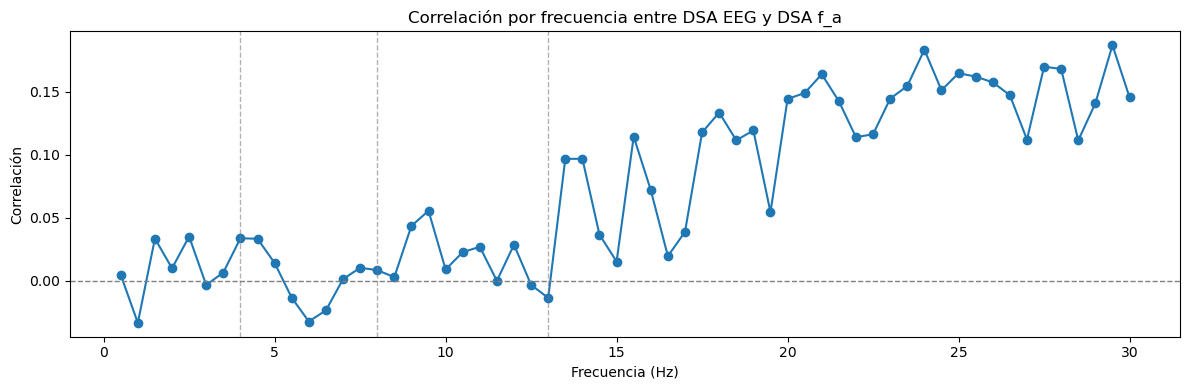

In [38]:
plt.figure(figsize=(12, 4))

plt.plot(
    df_corr_freq["frecuencia_Hz"],
    df_corr_freq["correlacion"],
    marker="o"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

for f in [4, 8, 13]:
    plt.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Correlación")
plt.title("Correlación por frecuencia entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()

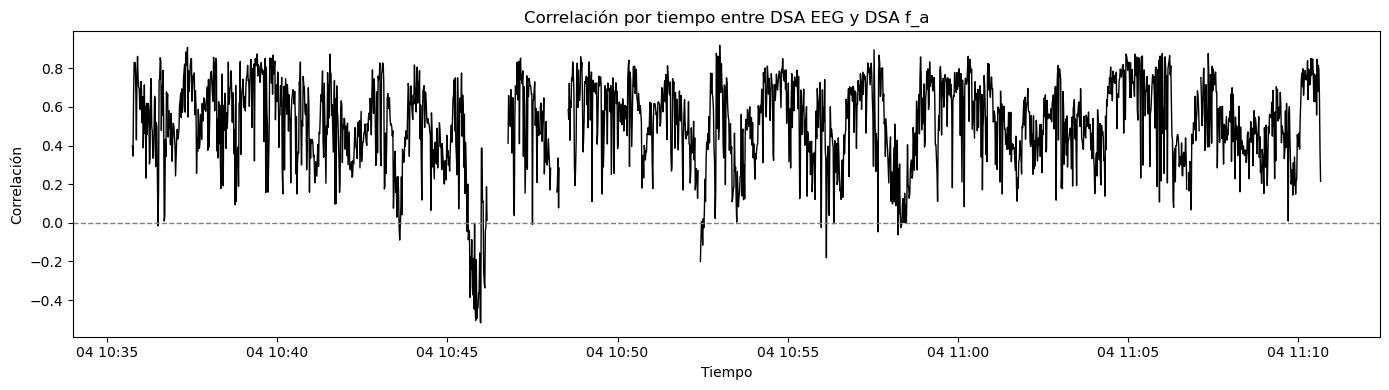

In [39]:
df_corr_tiempo = correlacion_por_tiempo(
    dsa_eeg_z,
    dsa_fa_z,
    tiempo=tiempo_fa_unilat
)

df_corr_tiempo.head()

plt.figure(figsize=(14, 4))

plt.plot(
    df_corr_tiempo["Time"],
    df_corr_tiempo["correlacion"],
    color="black",
    linewidth=1
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Tiempo")
plt.ylabel("Correlación")
plt.title("Correlación por tiempo entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()

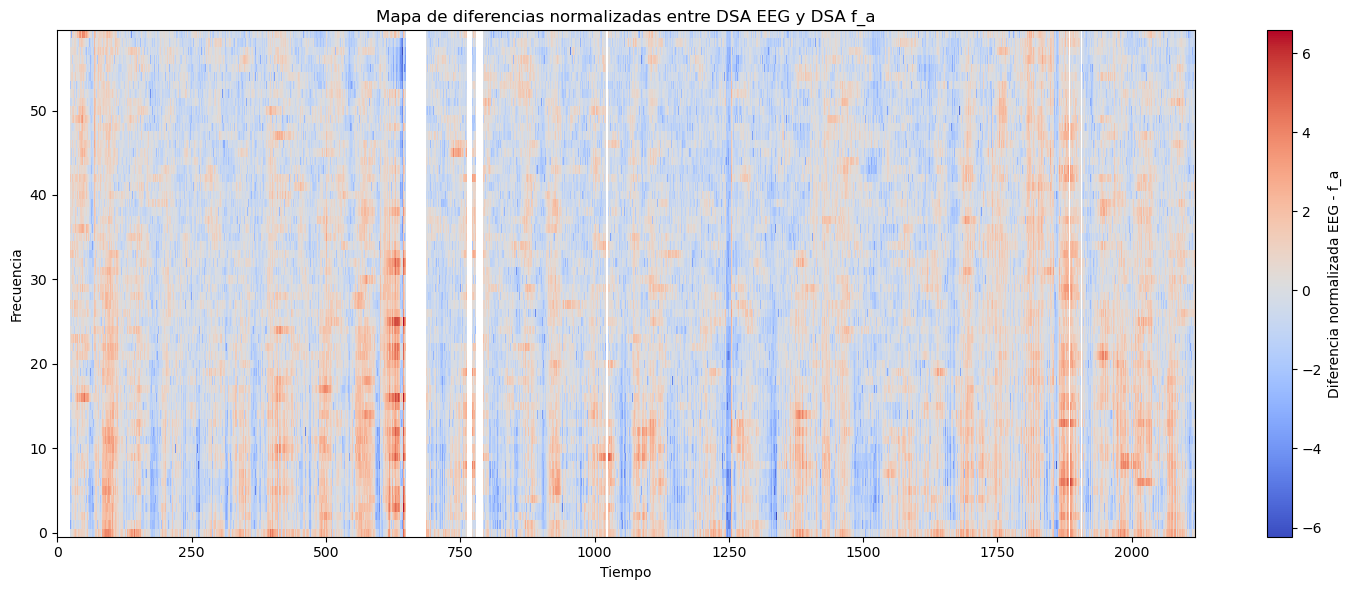

In [40]:
diferencia_z = dsa_eeg_z - dsa_fa_z

plt.figure(figsize=(15, 6))

plt.imshow(
    diferencia_z.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="coolwarm"
)

plt.colorbar(label="Diferencia normalizada EEG - f_a")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")
plt.title("Mapa de diferencias normalizadas entre DSA EEG y DSA f_a")
plt.tight_layout()
plt.show()

### archivo .h_a

In [ ]:
archivo_bin = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a" 

with open(archivo_bin, "rb") as archivo:
    contenido = archivo.read()

# 2. Vamos a ver los primeros 32 bytes en hexadecimal, separados por espacios
primeros_bytes = contenido[:32]
print("Datos en bruto (Hexadecimal):")
# print(contenido.hex(' '))

In [ ]:
fau.lectura_h_a(archivo_bin)

#### Datos extraídos del Encabezado (.h_a)
 - Nombre del archivo: L03041035.h_a

 - Fecha de inicio de la prueba: 4 de Marzo de 2026 a las 10:35:28 (Hora GMT)

 - Fecha de fin de la prueba: 4 de Marzo de 2026 a las 11:10:45 (Hora GMT)

 - Duración total calculada: 35 minutos y 17 segundos.

 - Motor/Algoritmo del monitor: BIS-R2 (Aparece repetido varias veces en la memoria, indicando la versión del software).

 - Filtro de paso alto configurado: 0.05 Hz (Aparece configurado para los canales internos).

 - Zona Horaria: GMT (Aparece explícitamente escrito casi al final del bloque).

## Dudas teoría Manual BIS Advanced

#### Microvoltios o Decibelios
El archivo crudo (.r2a) es puramente físico: 
 - En la página 32 del manual, define la Amplitud del EEG como la "tensión máxima absoluta de la forma de onda" y especifica claramente que "se expresa en microvoltios (µV)". Por tanto, esos números gigantes que extraíamos del .r2a eran efectivamente subidas y bajadas de microvoltaje puro. 


Las tablas .spa son matemáticas (dB): 
 - El manual confirma en la misma página que el EMG (y consecuentemente la potencia total) "se expresa en decibelios (dB) relativos a 0,0001 µV2". La máquina mide la electricidad bruta en el .r2a (microvoltios) y luego usa ecuaciones complejas para escupir resúmenes en decibelios en el .spa.

#### Tipos de archivos

.r2a y .r4a (EEG sin procesar): 
 - El manual aclara que la "r" es de Raw y el número indica los canales. 
 - El .r2a es para el sistema de 2 canales y el .r4a se genera cuando te ponen el sensor de 4 canales (Bilateral).


.spa (Archivo de variables procesadas): 
 - Aquí enumera que guarda el Índice Biespectral, el EMG, la Calidad de la Señal (ICS) y la Impedancia. Es exactamente la tabla inmensa de Pandas.


.h_a (El Encabezado): 
 - Números hexadecimales. 
 - .h_a incluye: la hora actual del monitor, la revisión de software, 4 números seguidos de -1, el tamaño del archivo crudo, y hora actual en hora Epoch/Unix.


## BIS ANTIGUO

### BIS BILATERAL


En la distribución del sensor Bilateral, los canales se asignan de la siguiente manera:

Canal 1: Temporal Izquierdo (LT)

Canal 2: Ojo Izquierdo (LE)

Canal 3: Temporal Derecho (RT)

Canal 4: Ojo Derecho (RE)

In [ ]:
ruta_spa_antiguo = "..\data\data_bis_antiguo\L04141330\L04141330.spa"
df_spa_antiguo = fau.procesar_spa(ruta_spa_antiguo)

display(df_spa_antiguo.head())
print(df_spa_antiguo.shape)
print(df_spa_antiguo.columns.tolist())

In [ ]:
# Contar cuántos segundos se han grabado
print(df_spa_antiguo.shape[0])

#### Comprobación de valores de campos pre-limpieza

In [ ]:
#busqueda= fau.buscar_filas_por_valor(df_spa_antiguo, "SEMG01_3", ">", 0)

In [ ]:
#busqueda[["Time", "SQI10", "SQI10_3", "TOTPOW08", "TOTPOW08_3", "ASYM09", "SBIS01", "SBIS01_3", "SEMG01", "SEMG01_3"]]

**Mantener Canal 1 y 3 (sin sufijo y el _3)**

 - Canal 1 (campos sin sufijo): Contiene todos los cálculos matemáticos (BIS, Tasa de Supresión, SEF, Burst, etc.) correspondientes al Hemisferio Izquierdo.

 - Canal 3 (campos acabados en _3): Contiene exactamente los mismos cálculos, pero evaluados para el Hemisferio Derecho.

Conservar ambos bloques (Ch 1 y Ch 3) para poder ver y comparar la evolución de los números BIS del lado izquierdo frente al lado derecho.


**Descartar Canal 2 (_2) y el Canal 4 (_4)**

 - Las variables procesadas complejas (como el número BIS o el EMG) no se calculan de forma aislada para los ojos, por lo que en tus datos verás que están rellenas con el código de error -3276.8.
 
Borrar todas las columnas que acaben en _2 y _4, a menos que interese conservar la Calidad de Señal (SQI) o la Impedancia física específica de esos electrodos frontales. 

**No borrar las variables exclusivas bilaterales**

In [ ]:
#busqueda[["Time", "SQI10", "SQI10_2", "SQI10_3", "SQI10_4", "TOTPOW08","TOTPOW08_2", "TOTPOW08_3", "TOTPOW08_4"]]

In [ ]:
#busqueda[["Time", "SQI10", "SQI10_2", "SQI10_3", "SQI10_4", "EMGLOW01","EMGLOW01_2", "EMGLOW01_3", "EMGLOW01_4"]]

In [ ]:
#busqueda[["Time", "SQI10", "SQI10_2", "SQI10_3", "SQI10_4", "ASYM09", "SBIS01", "SBIS01_3", "SEMG01", "SEMG01_3"]]

**Variabilidad del BIS y del EMG**

SBIS (Variabilidad del BIS): Es la desviación estándar del valor BIS a lo largo del último minuto. Te indica cuánto está fluctuando o cambiando el número BIS en ese hemisferio.

SEMG (Variabilidad del EMG): Es la desviación estándar de la actividad muscular (EMG) a lo largo del último minuto. Te indica cuánto está variando el tono muscular o la tensión frontal.

#### Exploración variables del Bilateral 4 canales

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, :20])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 20:27])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 27:42])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 42:47])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 47:62])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 62:67])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 67:82])

In [ ]:
#display(df_spa_antiguo.iloc[300: 340: 2, 82:])

#### Limpieza

In [ ]:
import funciones_aux

df_spa_limpio = fau.limpiar_spa_bilateral(df_spa_antiguo)

# Comprobamos cómo ha quedado el "antes y después"
print(f"\nForma ANTES de limpiar:  {df_spa_antiguo.shape}")
print(f"Forma DESPUÉS de limpiar: {df_spa_limpio.shape}")

print("\nNuevas columnas limpias listas para el análisis clínico:")
print(df_spa_limpio.columns.tolist())

In [ ]:
#display(df_spa_limpio.iloc[300: 340: 2, :20])

In [ ]:
#display(df_spa_limpio.iloc[300: 340: 2, 20:])

#### Tratamiento valores BIS

In [ ]:
import numpy as np

# 1. Extraemos el Tiempo y las 4 columnas clave (Crudo y Suavizado de cada lado)
df_bis_pantalla = df_spa_limpio[['Time', 'DB13U01', 'DB13U01_3']].copy()

# 2. Renombramos para que cualquiera pueda entender la tabla
df_bis_pantalla.columns = ['Tiempo', 'Izq_BIS_Crudo', 'Der_BIS_Crudo']

# 3. Limpiamos los -3276.8 (los segundos iniciales donde no había señal)
df_bis_pantalla.replace(-3276.8, np.nan, inplace=True)

#display(df_bis_pantalla.head(15))

En el archivo de texto, el campo correspondiente al valor verdadero del BIS suele aparecer etiquetado en el encabezado como B34... o DB1... (dependiendo del tipo de sensor), y da un valor decimal entre 0.0 y 100.0.

-----------------------------------------------------------------------------------------------------------------

### .r4a ondas crudas Bilateral 4 canales

**Formato de los datos (El tipo de variable)**

Cada muestra individual del EEG se guarda como un número entero con signo de 16 bits (16-bit signed integer) en formato de complemento a 2.


**Estructura intercalada (Multiplexación)**

Los canales no vienen separados en bloques, sino que se escriben de forma secuencial y repetitiva (intercalados muestra por muestra).
 - Al ser un archivo .r4a (4 canales), el orden de lectura de cada bloque de 16 bits es:
Canal 1 → Canal 2 → Canal 3 → Canal 4 → Canal 1 → Canal 2... y así sucesivamente hasta el final del archivo.


**Frecuencia de muestreo**

 - Toma 128 muestras por segundo para cada canal (128 Hz).
 - Esto significa que, por cada segundo de grabación física, el programa deberá leer 512 valores en total (128 muestras x 4 canales).
 
 
**Conversión a Microvoltios (La escala)**

 - El número entero que leas del archivo no es el voltaje directo. El manual especifica que los valores están en unidades de 0.05 µV.
 - Fórmula de procesamiento: Para obtener la amplitud real de la onda cerebral, debes coger el número entero extraído y multiplicarlo por 0.05. El resultado será el valor de la onda en microvoltios (µV).
 

**Manejo de errores o "huecos"**

 - Si se pierden paquetes de datos, el equipo mantiene la sincronización temporal del archivo rellenando ese hueco con datos de amplitud cero (0).

In [ ]:
def convertir_r4a_a_csv(archivo_entrada, archivo_salida):
    """
    Convierte un archivo de ondas crudas .r4a (Bilateral, 4 canales) a formato CSV.
    Basado en las especificaciones del monitor BIS: 
    - 128 muestras por segundo (Hz).
    - Los valores enteros se multiplican por 0.05 para obtener microvoltios (µV).
    
    Parámetros:
    - archivo_entrada (str): Ruta al archivo .r4a que se desea leer.
    - archivo_salida (str): Ruta donde se guardará el archivo .csv resultante.
    """
    print(f"Iniciando conversión de ondas crudas (BIS Bilateral) a 128 Hz...")
    print(f"Archivo origen: {archivo_entrada}")
    
    try:
        with open(archivo_entrada, "rb") as f_in, open(archivo_salida, "w") as f_out:
            # 1. Escribimos la cabecera indicando las unidades en microvoltios
            f_out.write("Tiempo_s,Canal_1_uV,Canal_2_uV,Canal_3_uV,Canal_4_uV\n")
            
            contador_muestras = 0
            
            # 2. Bucle de lectura de 8 en 8 bytes (4 canales * 2 bytes/canal)
            while True:
                bytes_muestra = f_in.read(8)
                if not bytes_muestra or len(bytes_muestra) < 8:
                    break
                
                # 3. Desempaquetar 4 enteros de 16 bits con signo ('<hhhh')
                canal_1, canal_2, canal_3, canal_4 = struct.unpack('<hhhh', bytes_muestra)
                
                # 4. Convertir a microvoltios (µV) multiplicando por 0.05
                c1_uv = canal_1 * 0.05
                c2_uv = canal_2 * 0.05
                c3_uv = canal_3 * 0.05
                c4_uv = canal_4 * 0.05
                
                # 5. Calcular tiempo en segundos usando la frecuencia de muestreo (128 Hz)
                tiempo_en_segundos = contador_muestras / 128.0
                
                # 6. Escribir en el CSV con 4 decimales de precisión
                f_out.write(f"{tiempo_en_segundos:.4f},{c1_uv:.4f},{c2_uv:.4f},{c3_uv:.4f},{c4_uv:.4f}\n")
                
                contador_muestras += 1

        print(f"- Muestras por canal procesadas: {contador_muestras}")
        print(f"- Tiempo total del registro: {contador_muestras / 128.0:.2f} segundos.")
        print(f"- Archivo guardado en: {os.path.abspath(archivo_salida)}\n")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{archivo_entrada}'. Por favor, verifica la ruta.\n")
    except Exception as e:
        print(f"Ocurrió un error inesperado al procesar el archivo: {e}\n")


In [ ]:
archivo_entrada = r"..\data\data_bis_antiguo\L04141330\L04141330.r4a"
archivo_salida = "voltajes_bilaterales.csv"

convertir_r4a_a_csv(archivo_entrada, archivo_salida)

1. La escala de tiempo (Tiempo_s)
 El equipo graba a una velocidad de 128 hercios (Hz). Esto significa que, por cada segundo que pasó en la realidad, hay 128 filas de datos.
 - Va avanzando en saltos de 0.0078 segundos (0.0000, 0.0078, 0.0156, etc.).
 
 
2. El mapa anatómico (Los canales)
Según el manual de especificaciones del sensor Bilateral, cada columna numérica corresponde a una pegatina específica en tu frente:

 - Canal_1_uV (LT - Temporal Izquierdo): Recoge la actividad cerebral de la sien izquierda.
 - Canal_2_uV (LE - Ojo Izquierdo): Recoge la actividad eléctrica por encima del ojo o ceja izquierda.
 - Canal_3_uV (RT - Temporal Derecho): Recoge la actividad cerebral de la sien derecha.
 - Canal_4_uV (RE - Ojo Derecho): Recoge la actividad eléctrica por encima del ojo o ceja derecha.
 

3. Los valores (_uV)
Los números que ves (por ejemplo, 12.4500 o -5.3000) son la amplitud del voltaje eléctrico medido en tu piel en ese milisegundo exacto, expresado en microvoltios (µV). Al ser ondas "crudas", este voltaje es una mezcla de varias cosas:

 - La electricidad generada por tus neuronas (las verdaderas ondas cerebrales).
 - La electricidad generada por tus músculos faciales (EMG).
 - El ruido eléctrico del ambiente (como la corriente de los enchufes a 50Hz o 60Hz).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos convertidos
archivo_csv = "voltajes_bilaterales.csv"
df = pd.read_csv(archivo_csv)

# 2. Definir una "ventana de tiempo" para hacer zoom (ej: 10 segundos)
# Puedes cambiar estos valores para explorar diferentes momentos de la cirugía
inicio_segundos = 1000 
fin_segundos = 1010

# Filtramos el dataframe para quedarnos solo con esa ventana
df_ventana = df[(df['Tiempo_s'] >= inicio_segundos) & (df['Tiempo_s'] <= fin_segundos)]

# 3. Configurar el estilo del gráfico "en plan EEG"
# Creamos 4 subgráficos apilados verticalmente que comparten el eje X (Tiempo)
fig, axs = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Señal Cruda de EEG - Ventana de {inicio_segundos}s a {fin_segundos}s', fontsize=16)

# Nombres de las columnas en tu CSV
canales = ['Canal_1_uV', 'Canal_2_uV', 'Canal_3_uV', 'Canal_4_uV']

# Detalle estético del monitor VISTA: Izquierda en amarillo, Derecha en azul
colores = ['#D4AC0D', '#D4AC0D', '#2874A6', '#2874A6']
nombres_clinicos = ['LT (Temporal Izq)', 'LE (Ojo Izq)', 'RT (Temporal Der)', 'RE (Ojo Der)']

# 4. Dibujar cada canal en su respectivo subgráfico
for i in range(4):
    axs[i].plot(df_ventana['Tiempo_s'], df_ventana[canales[i]], color=colores[i], linewidth=1)
    
    # Configuraciones estéticas para cada fila
    axs[i].set_ylabel(f'{nombres_clinicos[i]}\n(µV)', rotation=0, labelpad=50, ha='center', fontsize=10)
    axs[i].grid(True, linestyle='--', alpha=0.6)
    
    # Opcional: Fijar los límites del eje Y (ej. entre -100 y 100 µV) para evitar 
    # que un parpadeo deforme la escala, pero de momento dejamos que se autoajuste.
    # axs[i].set_ylim(-100, 100)

# Etiqueta del eje X solo en el último gráfico
axs[-1].set_xlabel('Tiempo (Segundos)', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Ajuste para que el título no se superponga
plt.show()

Es un error muy común al empezar a analizar señales biológicas, pero los microvoltios (µV) y los hercios (Hz) miden dos dimensiones completamente distintas de la física:

Los Microvoltios (µV): Miden la amplitud o fuerza eléctrica de la onda en un instante exacto. Te dicen "qué tan alto o bajo" es el pico de electricidad.

Los Hercios (Hz): Miden la frecuencia. Te dicen "cuántas veces" se repite esa onda en un segundo.

Transformación de Dominio
Lo que tú realmente necesitas hacer no es un "cambio de unidades", sino aplicar una operación matemática a todo el bloque de datos llamada Transformada Rápida de Fourier (FFT). Esta operación coge los miles de microvoltios de tu CSV y extrae las frecuencias (Hz) que están escondidas dentro de esos picos y valles.

Aquí tienes el script en Python para leer ese CSV que creamos antes, extraer exactamente los Hz de tu Canal 1 (Hemisferio Izquierdo) y calcular el porcentaje de cada tipo de onda cerebral que tenías en ese momento:

In [ ]:
import pandas as pd
import numpy as np
from scipy import signal

# 1. Cargar el archivo con las ondas crudas
archivo_csv = "voltajes_bilaterales.csv"
print("Cargando datos...")
df = pd.read_csv(archivo_csv)

# Vamos a analizar el Canal 1 (LT - Temporal Izquierdo)
# (Puedes cambiarlo al Canal 3 si quieres analizar el lado derecho)
canal_analizar = df['Canal_1_uV'].values

# Frecuencia de muestreo dictada por el monitor BIS
fs = 128  

# 2. Aplicar la matemática (Transformada de Fourier mediante método de Welch)
# Esto extrae las frecuencias (Hz) a partir de los voltajes (µV)
frecuencias, psd = signal.welch(canal_analizar, fs, nperseg=1024)

# 3. Definir los rangos de las ondas cerebrales en Hercios (Hz)
bandas_eeg = {
    'Ondas Delta (0.5 - 4 Hz) [Sueño profundo / Anestesia]': (0.5, 4),
    'Ondas Theta (4 - 8 Hz)   [Somnolencia]': (4, 8),
    'Ondas Alfa (8 - 13 Hz)   [Relajación con ojos cerrados]': (8, 13),
    'Ondas Beta (13 - 30 Hz)  [Despierto y concentrado]': (13, 30)
}

potencias_bandas = {}
potencia_total = 0

# 4. Calcular cuánta "energía" hay en cada banda de Hz
for nombre, (fmin, fmax) in bandas_eeg.items():
    # Encontrar qué frecuencias de nuestro cálculo caen en esta banda
    idx_banda = np.logical_and(frecuencias >= fmin, frecuencias <= fmax)
    
    # Calcular el área bajo la curva (potencia real) para esas frecuencias
    potencia_banda = np.trapz(psd[idx_banda], frecuencias[idx_banda])
    
    potencias_bandas[nombre] = potencia_banda
    potencia_total += potencia_banda

# 5. Imprimir los porcentajes
print("\n--- RESULTADOS DEL ELECTROENCEFALOGRAMA ---")
for nombre, potencia in potencias_bandas.items():
    porcentaje = (potencia / potencia_total) * 100
    print(f"{nombre}: {porcentaje:.2f}%")

En lugar de mirar voltaje por voltaje, coge todo tu historial de la sien izquierda (Canal_1_uV).

Utiliza la función signal.welch para hacer el equivalente a pasar la luz blanca por un prisma: separa la señal compleja en todos los colores (frecuencias en Hz) que la forman.

Suma la cantidad de señal que hay en los rangos médicos conocidos (Delta, Theta, Alfa y Beta).

Te devuelve un porcentaje limpio (ej. 45.20% de Ondas Delta), que te dirá instantáneamente en qué estado de consciencia o relajación se encontraba tu cerebro en esa grabación.

In [ ]:
archivo_r4a = r"..\data\data_bis_antiguo\L04141330\L04141330.r4a"
ruta_spa_antiguo = "..\data\data_bis_antiguo\L04141330\L04141330.spa"
df_spa_antiguo = fau.procesar_spa(ruta_spa_antiguo)

In [ ]:
# 1. Leer EEG crudo bilateral .r4a
df_eeg_bilateral = fun_dsa.leer_r4a(
    archivo_r4a,
    fs=128,
    escala_uv=0.0511
)

# 2. Crear DSA del canal 1
df_dsa_ch1, frecuencias = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilateral,
    fs=128,
    canal="canal_1_uV",
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="db",
    tiempo_referencia="centro"
)

# 3. Crear DSA del canal 3
df_dsa_ch3, _ = fun_dsa.crear_matriz_dsa_fft_welch_desde_eeg(
    df_eeg_bilateral,
    fs=128,
    canal="canal_3_uV",
    ventana_seg=2,
    paso_seg=1,
    fmin=0.5,
    fmax=30.0,
    paso_freq=0.5,
    modo="db",
    tiempo_referencia="centro"
)

# 4. Preparar .spa y obtener hora de inicio automáticamente
df_spa_antiguo, hora_inicio = fun_dsa.obtener_hora_inicio_desde_spa(df_spa_antiguo)

# 5. Adaptar DSA canal 1 al formato de plot
tiempo_ch1, dsa_ch1 = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_ch1,
    frecuencias=frecuencias,
    hora_inicio=hora_inicio
)

# 6. Adaptar DSA canal 3 al formato de plot
tiempo_ch3, dsa_ch3 = fun_dsa.adaptar_dsa_reconstruida_para_plot(
    df_dsa=df_dsa_ch3,
    frecuencias=frecuencias,
    hora_inicio=hora_inicio
)

# 7. Comprobar que los tiempos coinciden
if not (tiempo_ch1.values == tiempo_ch3.values).all():
    raise ValueError("Los tiempos de canal 1 y canal 3 no coinciden.")

tiempo = tiempo_ch1

# 8. Alinear .spa con los tiempos de la DSA
df_merge = fun_dsa.alinear_spa_con_tiempo(
    tiempo=tiempo,
    df_spa=df_spa_antiguo
)

# 9. Aplicar máscaras blancas a canal 1
dsa_plot_ch1, mask_total_ch1 = fun_dsa.preparar_dsa_para_plot(
    tiempo=tiempo,
    dsa=dsa_ch1,
    df_merge=df_merge,
    umbral_sqi=14,
    umbral_ceros=0.9
)

# 10. Aplicar máscaras blancas a canal 3
dsa_plot_ch3, mask_total_ch3 = fun_dsa.preparar_dsa_para_plot(
    tiempo=tiempo,
    dsa=dsa_ch3,
    df_merge=df_merge,
    umbral_sqi=14,
    umbral_ceros=0.9
)

# 11. Crear máscara común
mask_total = mask_total_ch1 | mask_total_ch3

dsa_plot_ch1.loc[mask_total.values, :] = np.nan
dsa_plot_ch3.loc[mask_total.values, :] = np.nan

# 12. Preparar escala de color común
matriz_ch1, matriz_ch3, vmin, vmax, norm, cmap = fun_dsa.preparar_escala_color_dsa_bilateral(
    dsa_plot_ch1,
    dsa_plot_ch3,
    gamma=0.55
)

# 13. Opcional: ocultar SEF/MEF en zonas no válidas
df_merge_plot = df_merge.copy()

for col in ["SEF08", "MEDFRQ08"]:
    if col in df_merge_plot.columns:
        df_merge_plot.loc[mask_total.values, col] = np.nan

# 14. Pintar DSA bilateral
fun_dsa.plot_dsa_bilateral_con_sef_mef(
    tiempo=tiempo,
    frecuencias=frecuencias,
    matriz_ch1=matriz_ch1,
    matriz_ch3=matriz_ch3,
    norm=norm,
    cmap=cmap,
    df_merge=df_merge_plot,
    titulo_ch1="DSA bilateral reconstruida - Canal 1",
    titulo_ch3="DSA bilateral reconstruida - Canal 3",
    mostrar_sef=True,
    mostrar_mef=True
)

In [ ]:
print(df_eeg_bilateral.shape)

print(df_dsa_ch1.shape)
print(df_dsa_ch3.shape)

print(frecuencias[:5])
print(frecuencias[-5:])

print("Tiempos iguales:", (tiempo_ch1.values == tiempo_ch3.values).all())

print("NaN canal 1:", np.isnan(matriz_ch1).sum())
print("NaN canal 3:", np.isnan(matriz_ch3).sum())

print("vmin:", vmin)
print("vmax:", vmax)